# ClosetAI · Diagnosi dello stato del capo
## Testa MLP addestrata su embedding Fashion-CLIP congelati

**Stato nel prodotto:** modello di produzione. Il backend carica il
checkpoint `ml/weights/condition_head.pt`; se manca, usa un fallback
euristico.

**Domanda:** una foto mostra un capo `buono`, `usurato` o
`danneggiato`?

La rete Fashion-CLIP è **pre-addestrata da terzi e congelata**. Noi
addestriamo soltanto una piccola testa neurale MLP:

`foto → Fashion-CLIP (512 feature) → 256 → 128 → 3 classi`

Il notebook non sovrascrive i pesi dell'app: riproduce il training e
rende visibili dati, scelte, metriche e limiti per l'esame.

In [1]:
# Trova la radice del repository anche se Jupyter parte da una sottocartella.
from pathlib import Path

def find_project_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "backend" / "pyproject.toml").is_file() and (candidate / "ml").is_dir():
            return candidate
    raise FileNotFoundError("Radice di ClosetAI non trovata")

ROOT = find_project_root()
SEED = 42
print(f"Repository: {ROOT}")

Repository: C:\devel\closet-ai


In [2]:
# Import riproducibili. Gli embedding CLIP sono già in cache: in questo
# modo l'esame non dipende dalla rete o da un download di ~600 MB.
import copy
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)

DATA_DIR = ROOT / "ml" / "datasets" / "garment_condition"
manifest = pd.read_csv(DATA_DIR / "manifest.csv")
cached = np.load(DATA_DIR / "clip_embeddings.npz", allow_pickle=True)
X = cached["X"].astype("float32")
y = cached["y"].astype("int64")
split = cached["split"].astype(str)
LABELS = ["buono", "usurato", "danneggiato"]

assert len(manifest) == len(X) == len(y) == len(split)
assert X.shape[1] == 512
print(f"Campioni: {len(X)} · embedding: {X.shape[1]}D")
pd.crosstab(manifest["split"], manifest["condition"])

Campioni: 600 · embedding: 512D


condition,buono,danneggiato,usurato
split,,,
test,32,27,24
train,141,140,137
val,27,33,39


### Provenienza dei dati

Il dataset è ibrido: immagini con difetti reali dal dataset COCO
*Defect-Clothes* e degradazioni sintetiche controllate per simulare
l'usura. Il vantaggio è poter costruire una pipeline completa; il
limite è il possibile **domain gap** rispetto alle foto scattate da
utenti reali. Inoltre il dataset locale è risuddiviso casualmente e
non conserva gli split originali della sorgente: campioni correlati
non sono esclusi con certezza fra train e test. Perciò l'accuracy qui
sotto è un **holdout del prototipo**, non una validazione esterna né
una certificazione industriale.

In [3]:
# Separiamo usando lo split già scritto nel manifest. Il test resta
# escluso da ogni decisione di training e early stopping.
masks = {name: split == name for name in ("train", "val", "test")}
tensors = {}
for name, mask in masks.items():
    tensors[name] = (
        torch.tensor(X[mask], dtype=torch.float32),
        torch.tensor(y[mask], dtype=torch.long),
    )
    print(name, tensors[name][0].shape)

def build_model():
    return nn.Sequential(
        nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.30),
        nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.30),
        nn.Linear(128, 3),
    )

model = build_model()
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parametri addestrabili della nostra testa: {trainable:,}")
model

train torch.Size([418, 512])
val torch.Size([99, 512])
test torch.Size([83, 512])
Parametri addestrabili della nostra testa: 164,611


Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=128, out_features=3, bias=True)
)

Stop a epoca 43; best validation accuracy=0.960; tempo=0.3s


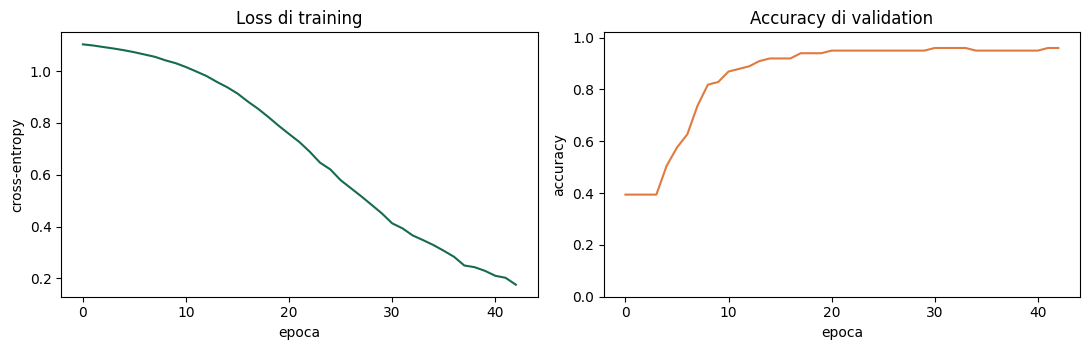

In [4]:
# Full-batch training: il dataset è piccolo. Adam + weight decay
# riduce l'overfitting; early stopping usa soltanto la validation.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
history = {"train_loss": [], "val_accuracy": []}
best_val, best_state, stale = -1.0, None, 0
patience, max_epochs = 12, 120
Xtr, ytr = tensors["train"]
Xva, yva = tensors["val"]

started = time.perf_counter()
for epoch in range(1, max_epochs + 1):
    model.train()
    optimizer.zero_grad()
    loss = criterion(model(Xtr), ytr)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_accuracy = (model(Xva).argmax(1) == yva).float().mean().item()
    history["train_loss"].append(loss.item())
    history["val_accuracy"].append(val_accuracy)

    if val_accuracy > best_val:
        best_val = val_accuracy
        best_state = copy.deepcopy(model.state_dict())
        stale = 0
    else:
        stale += 1
    if stale >= patience:
        break

model.load_state_dict(best_state)
print(f"Stop a epoca {epoch}; best validation accuracy={best_val:.3f}; tempo={time.perf_counter()-started:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(history["train_loss"], color="#176B4D")
axes[0].set(title="Loss di training", xlabel="epoca", ylabel="cross-entropy")
axes[1].plot(history["val_accuracy"], color="#E07A3F")
axes[1].set(title="Accuracy di validation", xlabel="epoca", ylabel="accuracy", ylim=(0, 1.02))
plt.tight_layout(); plt.show()

TEST accuracy: 0.940
              precision    recall  f1-score   support

       buono      0.935     0.906     0.921        32
     usurato      0.885     0.958     0.920        24
 danneggiato      1.000     0.963     0.981        27

    accuracy                          0.940        83
   macro avg      0.940     0.943     0.941        83
weighted avg      0.942     0.940     0.940        83



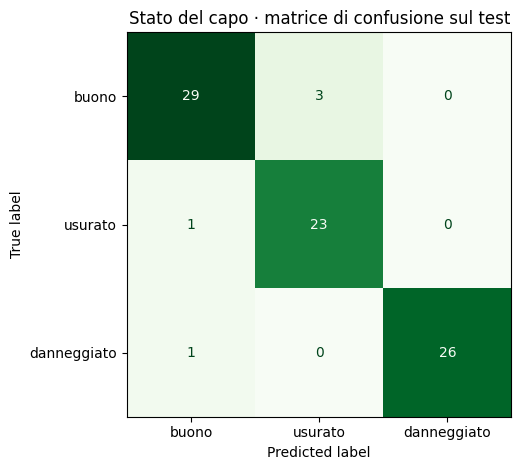

In [5]:
# Il test viene aperto una sola volta, dopo aver fissato il modello.
Xte, yte = tensors["test"]
model.eval()
with torch.no_grad():
    logits = model(Xte)
    predictions = logits.argmax(1).numpy()
    probabilities = logits.softmax(1).numpy()

test_accuracy = float((predictions == yte.numpy()).mean())
print(f"TEST accuracy: {test_accuracy:.3f}")
print(classification_report(yte.numpy(), predictions, target_names=LABELS, digits=3, zero_division=0))

cm = confusion_matrix(yte.numpy(), predictions)
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(cmap="Greens", colorbar=False)
plt.title("Stato del capo · matrice di confusione sul test")
plt.tight_layout(); plt.show()

In [6]:
# Esempio di inferenza completamente tracciabile su un campione test.
idx = 0
true_label = LABELS[int(yte[idx])]
pred_label = LABELS[int(predictions[idx])]
table = pd.Series(probabilities[idx], index=LABELS, name="probabilità").sort_values(ascending=False)
print(f"Vero: {true_label} · Predetto: {pred_label}")
table.to_frame()

Vero: buono · Predetto: buono


,probabilità
buono,0.582410
usurato,0.302085
danneggiato,0.115504


### Cosa dire all'esame

- Abbiamo congelato Fashion-CLIP e addestrato solo circa 164 mila
  parametri: è **transfer learning**, non training da zero.
- Accuracy e confusion matrix misurano cose diverse: la seconda fa
  vedere *quali* stati vengono confusi.
- L'early stopping usa validation; il test non guida il training.
- Il limite principale non è l'architettura ma la rappresentatività
  delle foto. Prima di un rilascio servono dati reali, consenso,
  analisi dei bias e una valutazione per condizioni di luce/camera.